In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

# Load data
data = pd.read_csv('superstore_dataset.csv', encoding='latin-1')

# Basic exploration
print(data.shape)
print(data.dtypes)
print(data.isnull().sum())
data.head()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Preprocessing
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date']  = pd.to_datetime(data['Ship Date'])
data['Year']       = data['Order Date'].dt.year
data['Month']      = data['Order Date'].dt.to_period('M').astype(str)

print("Date range:", data['Order Date'].min(), "→", data['Order Date'].max())
print("Nulls after cleaning:\n", data.isnull().sum())

Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00
Nulls after cleaning:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64


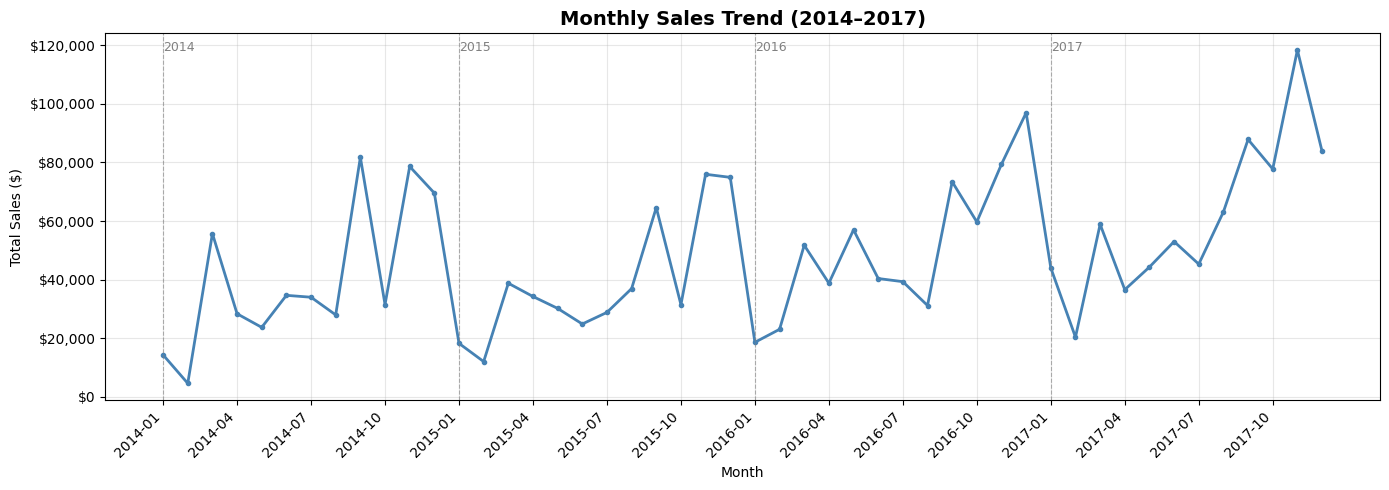

In [3]:
sales_by_month = (
    data.groupby('Month')['Sales']
    .sum()
    .reset_index()
    .sort_values('Month')
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sales_by_month['Month'], sales_by_month['Sales'],
        color='steelblue', linewidth=2, marker='o', markersize=3)

# Highlight yearly boundaries
for year in data['Year'].unique():
    first_month = f"{year}-01"
    if first_month in sales_by_month['Month'].values:
        ax.axvline(x=sales_by_month[sales_by_month['Month'] == first_month].index[0],
                   color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.text(sales_by_month[sales_by_month['Month'] == first_month].index[0],
                ax.get_ylim()[1] * 0.95, str(year), fontsize=9, color='gray')

ax.set_title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Reduce x-tick clutter — show every 3rd label
ticks = range(0, len(sales_by_month), 3)
ax.set_xticks(list(ticks))
ax.set_xticklabels([sales_by_month['Month'].iloc[i] for i in ticks], rotation=45, ha='right')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# pip install plotly if needed
import plotly.express as px

sales_by_state = data.groupby('State')['Sales'].sum().reset_index()

fig = px.choropleth(
    sales_by_state,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    color_continuous_scale='Blues',
    title='Total Sales by State',
    labels={'Sales': 'Total Sales ($)'}
)

fig.update_layout(title_font_size=16)
fig.show()

C:\Users\typal\AppData\Local\Temp\ipykernel_19340\1011752770.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


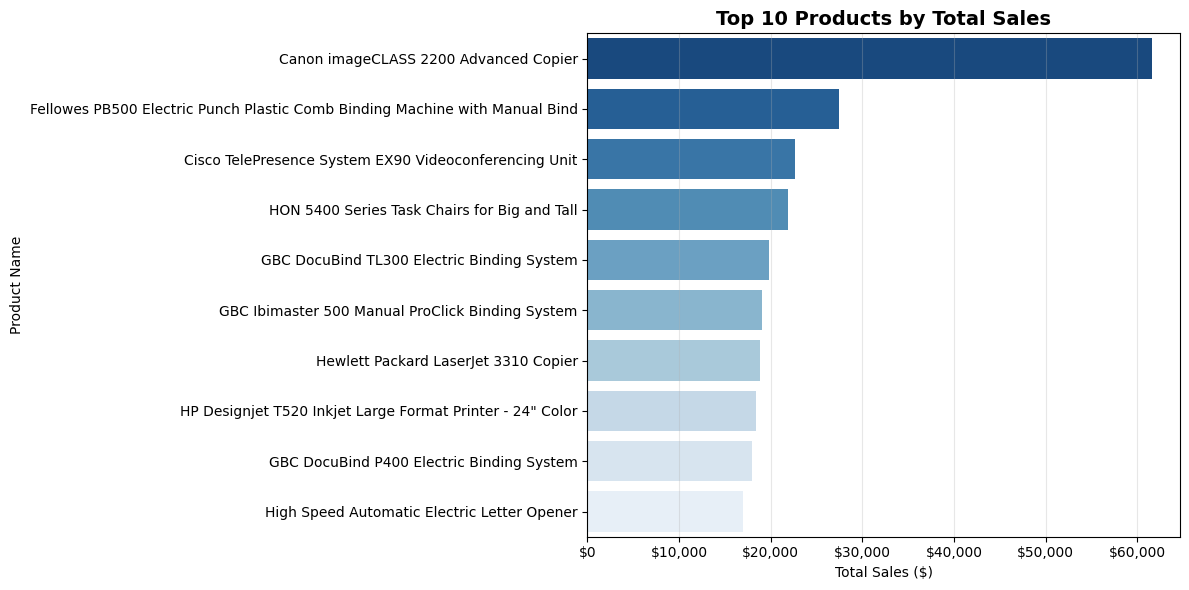

In [5]:
top_products = (
    data.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_products,
    x='Sales',
    y='Product Name',
    palette='Blues_r',
    ax=ax
)

ax.set_title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Product Name')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

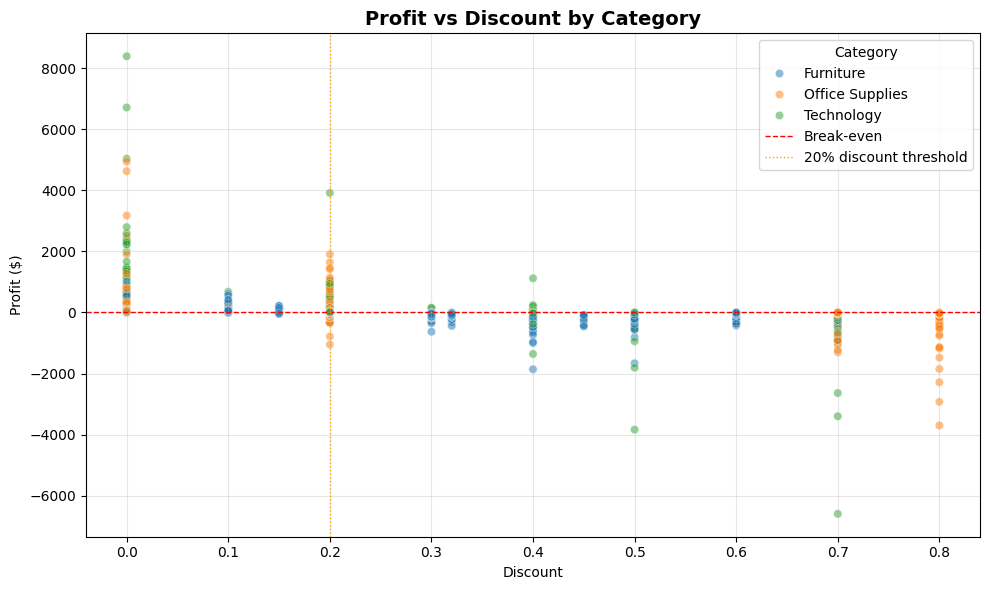

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.5,
    ax=ax
)

ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.axvline(0.2, color='orange', linestyle=':', linewidth=1, label='20% discount threshold')

ax.set_title('Profit vs Discount by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.legend(title='Category')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Matplotlib vs Seaborn — Comparative Analysis

### Line Chart & Map (Matplotlib / Plotly)
- Matplotlib gives full control over every element (ticks, labels, grid, annotations)
- More verbose — a simple styled chart requires 10–15 lines vs 3–4 in Seaborn
- Plotly adds interactivity (hover, zoom) with minimal extra code — better for maps and time series exploration

### Bar Chart & Scatter Plot (Seaborn)
- Seaborn produces publication-quality visuals with far less code
- `hue='Category'` automatically splits and colors by group — would take manual looping in Matplotlib
- Less flexible for fine-grained customization; underlying Matplotlib calls needed for edge cases

### Key Observations from the Data
- **Sales trend:** Clear year-end spikes (Q4) every year — seasonal demand pattern
- **Top products:** Canon imageCLASS copiers and Cisco phones dominate sales
- **Profit vs Discount:** Strong negative correlation above 20% discount — 
  orders with discounts over 0.4 are almost universally unprofitable across all categories
- **Conclusion:** Discounting is the single biggest driver of negative profit in this dataset

### Verdict
| Task | Better Tool |
|---|---|
| Quick grouped charts | Seaborn |
| Custom annotated charts | Matplotlib |
| Interactive maps / time series | Plotly |
| Statistical plots (box, violin, heatmap) | Seaborn |